In [ ]:
import sys
sys.path.insert(0, 'pythonlib')

import pandas as pd
from enginewash import WashCalculator, FlightRecord, FlightPhase, MaintenanceRecord, EGTHDM

# Записи о техническом обслуживании
# 223 — очистка коннекторов
# 224 — замена термопары
# 330-340 — промывка водой и растворами

# columns : engine_id, maint_datetime, ata_code, ata_classification, reason, creation_datetime
maintenance = pd.read_parquet('https://storage.yandexcloud.net/ecm-data/ecmapp.maintenance_20260222.parquet')

# Отчеты, записанные в фазу круиза
# columns : ['aircraft_id', 'engine_position', 'flight_datetime', 'zpcn12', 'zpcn25',
    #    'zpoil', 'zt49', 'ztoil', 'zvb1f', 'zwf36', 'brat', 'degt', 'dpoil',
    #    'egtc', 'egthdm', 'gegtmc', 'gn2mc', 'gpcn25', 'gwfm', 'pcn12',
    #    'pcn12i', 'pcn1k', 'pcn2c', 'pip_bled', 'pip_etop', 'pip_oilm',
    #    'pip_pem', 'pip_vlcr', 'pip_xn1c', 'sloatl', 'wbi', 'wfmp', 'zpcn25_d',
    #    'zt49_d', 'zwf36_d', 'agw', 'ibe1', 'ibe2', 'ibp1', 'ibp2', 'ivs12',
    #    'sat', 'zalt', 'zt1a', 'zxm', 'engine_id', 'n1_modifier'],

data_cruise = pd.read_parquet('https://storage.yandexcloud.net/ecm-data/s7.b737_cruise_20260222-merged.parquet')

# Отчеты, записанные на взлете
data_takeoff  = pd.read_parquet('https://storage.yandexcloud.net/ecm-data/s7.b737_takeoff_20260222-merged.parquet')

In [ ]:
# use engine wash library to calculate wash effects for takeoff (for EGTHDM parameter only)
wash_maint = maintenance[maintenance['ata_code'].astype(str).str.match(r'^3[34]\d$')]

takeoff = data_takeoff[['engine_id', 'flight_datetime', 'egthdm']].dropna()
takeoff = takeoff.assign(engine_id=takeoff['engine_id'].astype(int).astype(str))

flights = [
    FlightRecord(
        engine_id=row.engine_id,
        flight_datetime=row.flight_datetime,
        parameter_name="EGTHDM",
        flight_phase=FlightPhase.TAKEOFF,
        float_value=row.egthdm,
    )
    for row in takeoff.itertuples()
]

maintenance_records = [
    MaintenanceRecord(
        engine_id=str(row.engine_id),
        maint_datetime=row.maint_datetime.tz_localize(None),
        ata_code=str(row.ata_code),
    )
    for row in wash_maint[['engine_id', 'maint_datetime', 'ata_code']].itertuples()
]

calc = WashCalculator()
summaries = calc.process(flights=flights, maintenance=maintenance_records, parameter=EGTHDM)

summaries

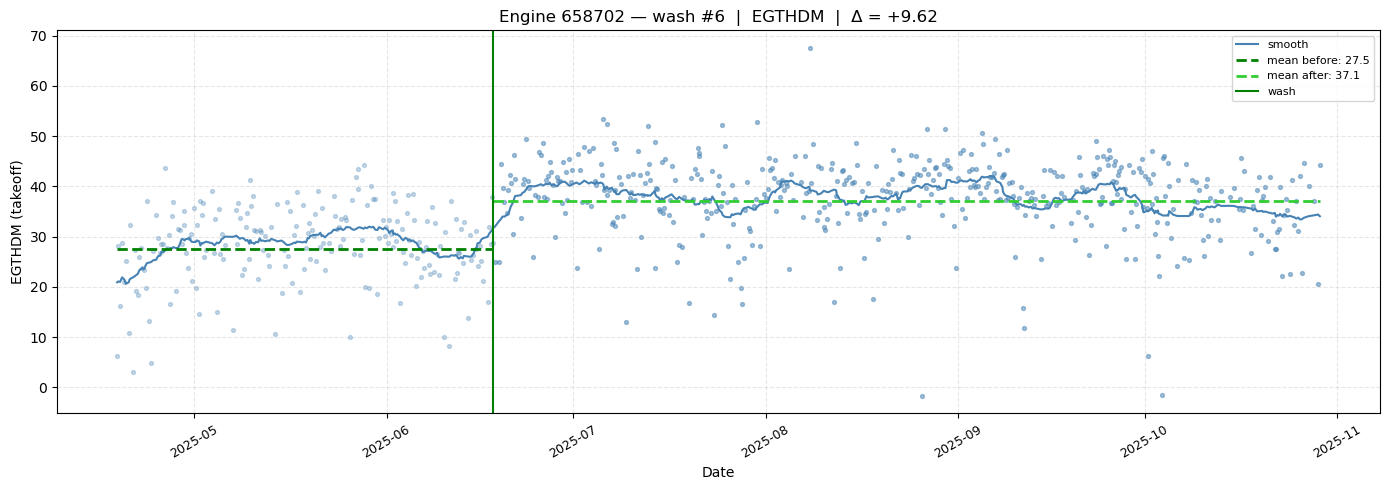

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from enginewash import smooth_series

eid = "658702"
all_events = [ev for s in summaries for ev in s.results]
event = next(
    ev for ev in reversed(all_events)
    if ev.engine_id == eid
)

wash_time = event.maint_datetime
window_start = wash_time - pd.DateOffset(months=2)

pts = (
    takeoff[takeoff["engine_id"] == eid]
    .sort_values("flight_datetime")
    .query("flight_datetime >= @window_start")
    .copy()
)

before = pts[pts["flight_datetime"] < wash_time]
after  = pts[pts["flight_datetime"] >= wash_time]

pts["smooth"] = smooth_series(pts["egthdm"], window=30, fallback=pts["egthdm"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(before["flight_datetime"], before["egthdm"], s=8, color="steelblue", alpha=0.3)
ax.scatter(after["flight_datetime"],  after["egthdm"],  s=8, color="steelblue", alpha=0.5)
ax.plot(pts["flight_datetime"], pts["smooth"], color="steelblue", linewidth=1.5, label="smooth")

ax.hlines(event.mean_before, before["flight_datetime"].min(), wash_time,
          colors="green", linewidths=2, linestyles="--", label=f"mean before: {event.mean_before:.1f}")

after_end = event.time_loss_of_efficiency or after["flight_datetime"].max()
ax.hlines(event.mean_after, wash_time, after_end,
          colors="limegreen", linewidths=2, linestyles="--", label=f"mean after: {event.mean_after:.1f}")

ax.axvline(wash_time, color="green", linewidth=1.5, label="wash")

if event.time_loss_of_efficiency:
    ax.axvline(event.time_loss_of_efficiency, color="red", linewidth=1.5, linestyle="--", label="loss of efficiency")

ax.set_title(f"Engine {eid} — wash #{event.event_index}  |  EGTHDM  |  Δ = {event.delta:+.2f}")
ax.set_xlabel("Date")
ax.set_ylabel("EGTHDM (takeoff)")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.tick_params(axis="x", which="major", labelsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both", linestyle="--")
plt.tight_layout()
plt.show()

1. Предусмотреть выбор критериев Время, часы (disabled), циклы (disabled)
2. Предусмотреть настройку конфигурации модуля (mean before, after, smooth window)
3. Настройка количества точек промывок (???) by date / __by point__
4. one vs multiple acnum selector
